In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [7]:
samples = np.load(f"../../../../output/age_depth_unified_cap/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified_cap/energy_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified_cap/bias_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_unified_cap/resamp_{config_str}.npy")

In [8]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(4, 9900, 10)
(4, 10000, 10)


In [9]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [10]:
print(energy_values)

[[289.26191578 169.93318679  97.45900328 ...  28.18025334  30.72350517
   28.67668296]
 [110.9977208   77.55268527  59.2751295  ...  31.61587959  34.34954952
   32.32574188]
 [235.56631906 222.26429063 215.4058011  ...  44.95064201  44.8288431
   44.84645629]
 [ 92.43932629  89.49383022  64.37364087 ...  41.49663634  42.24023922
   42.81586341]]


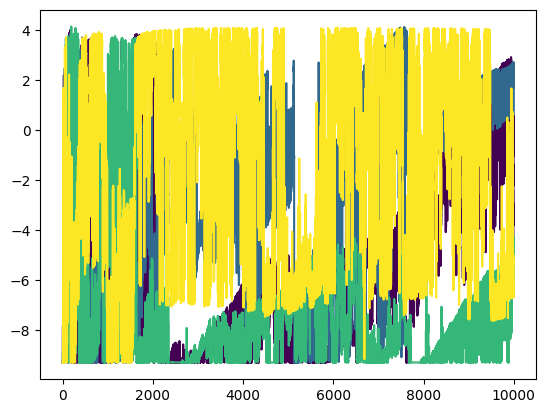

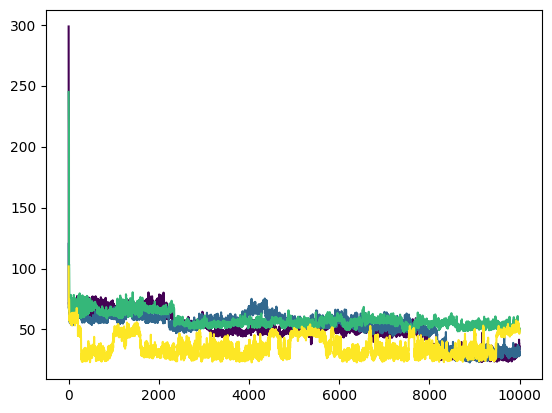

In [11]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


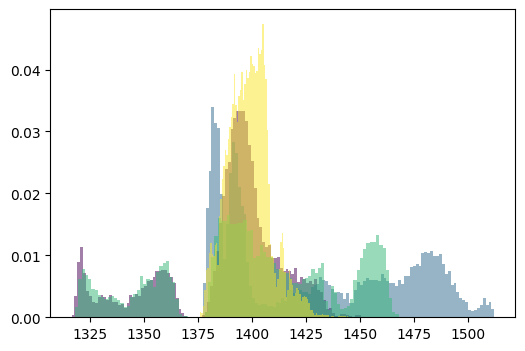

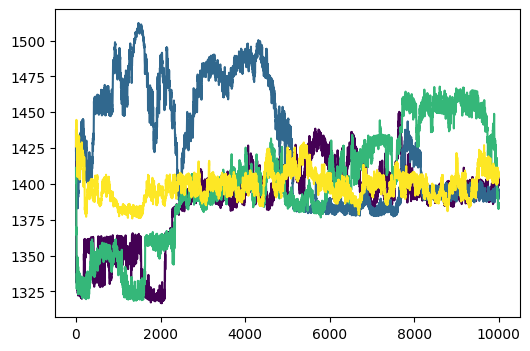

In [12]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
resampled_samples = resampled_samples[:,::1000,:]

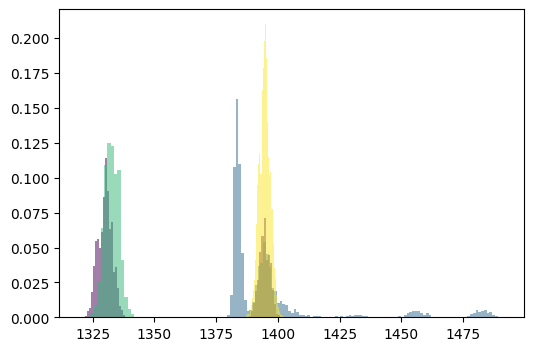

In [13]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [ ]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [ ]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

              mean            sd  hdi_3%       hdi_97%     mcse_mean  \
x[0]  1.070000e+00  7.200000e+00    0.00  1.000000e-02  7.400000e-01   
x[1]  1.890000e+00  1.279000e+01    0.00  1.200000e-01  5.400000e-01   
x[2]  3.000000e-02  1.020000e+00    0.00  5.000000e-02  2.000000e-02   
x[3]  0.000000e+00  3.000000e-02    0.00  1.000000e-02  0.000000e+00   
x[4]  7.600000e-01  7.310000e+00    0.00  7.000000e-02  1.800000e-01   
x[5]  1.746128e+07  4.796441e+07    0.01  1.055715e+08  1.090692e+07   
x[6]  7.000000e-02  1.400000e-01    0.00  3.200000e-01  6.000000e-02   
x[7]  3.228573e+10  7.584919e+10    0.00  1.288264e+11  2.808944e+10   
x[8]  3.241205e+08  1.033090e+09    0.00  1.588239e+09  2.737619e+08   
x[9]  3.580136e+04  3.784408e+05    0.00  1.660023e+05  3.007197e+04   

           mcse_sd  ess_bulk  ess_tail  r_hat  
x[0]  1.910000e+00      5.12     24.00   2.19  
x[1]  9.500000e-01      6.21     28.89   1.71  
x[2]  4.400000e-01      4.77     26.54   2.56  
x[3]  2.000000e

In [ ]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()